1. Импорт библиотек и настройка окружения

In [ ]:
import os
import cv2
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

from ultralytics import YOLO

import torch

plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10
sns.set_style('whitegrid')

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(42)
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

CUDA available: True
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


2. Загрузка и предобработка данных  
Датасет HRPlanes содержит:   
Изображения высокого разрешения: 4800×2703 пикселей, RGB формат   
Аннотации в формате YOLO: .txt файлы с координатами class_id x_center y_center width height(нормализованные)   

In [3]:
def parse_yolo_annotation(label_path, img_width, img_height):
    """
    Парсинг аннотации в формате YOLO
    Возвращает: список словарей {class_id, x1, y1, x2, y2} в пикселях
    """
    bboxes = []
    if not os.path.exists(label_path):
        return bboxes
    
    with open(label_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) != 5:
                continue
            class_id = int(parts[0])
            # YOLO формат: x_center, y_center, width, height (нормализованные 0-1)
            x_c, y_c, w, h = map(float, parts[1:])
            
            # Конвертация в пиксели и в формат [x1, y1, x2, y2]
            x1 = int((x_c - w/2) * img_width)
            y1 = int((y_c - h/2) * img_height)
            x2 = int((x_c + w/2) * img_width)
            y2 = int((y_c + h/2) * img_height)
            
            # Клиппинг к границам изображения
            x1, y1 = max(0, x1), max(0, y1)
            x2, y2 = min(img_width, x2), min(img_height, y2)
            
            bboxes.append({
                'class_id': class_id,
                'x1': x1, 'y1': y1, 'x2': x2, 'y2': y2,
                'x_c_norm': x_c, 'y_c_norm': y_c, 
                'w_norm': w, 'h_norm': h
            })
    return bboxes


def calculate_iou(box1, box2):
    """
    Вычисление IoU (Intersection over Union) для двух bounding box
    box: [x1, y1, x2, y2]
    """
    x1_min = max(box1[0], box2[0])
    y1_min = max(box1[1], box2[1])
    x1_max = min(box1[2], box2[2])
    y1_max = min(box1[3], box2[3])
    
    intersection = max(0, x1_max - x1_min) * max(0, y1_max - y1_min)
    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union = area1 + area2 - intersection
    
    return intersection / union if union > 0 else 0

3. Построение и обучение модели

In [4]:
MODEL_NAME = "yolov8n.pt" 
model = YOLO(MODEL_NAME)

# Информация о модели
print(f"Модель загружена")
print(f"   Классы по умолчанию: {model.names}")
print(f"   Задача: {model.task}")

Модель загружена
   Классы по умолчанию: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant', 59: 'bed', 60: 'dining table', 61: 'toilet', 62: 'tv', 63: 'laptop', 64: 'mouse', 65: 'remote', 66: 

In [ ]:
from ultralytics import YOLO
import torch

# Путь к новому конфгу
DATA_CONFIG = str("data/yolo_format/dataset.yaml")

model = YOLO("yolov8n.pt")  # или yolov8s.pt для лучшей точности

TRAIN_CONFIG = {
    'data': DATA_CONFIG,
    'epochs': 15,
    'imgsz': 640,
    'batch': 16,
    
    'mosaic': 1.0,      # Mosaic-аугментация
    'mixup': 0.1,       # MixUp
    'fliplr': 0.5,      # Горизонтальный флип
    'scale': 0.5,       # Масштабирование
    'translate': 0.1,   # Сдвиг
    'hsv_h': 0.015,     # Hue
    'hsv_s': 0.7,       # Saturation
    'hsv_v': 0.4,       # Brightness
    
    'optimizer': 'AdamW',
    'lr0': 0.001,
    'patience': 15,
    'project': 'runs/detect',
    'name': 'lab3_plane_detection',
    'device': '0' if torch.cuda.is_available() else 'cpu',
    'workers': 4,
    'plots': True,
    'verbose': False,
}

results = model.train(**TRAIN_CONFIG)
print(f"Обучение завершено!")

Ultralytics 8.4.53  Python-3.12.6 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data\plane\yolo_format\dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=lab3_plane_detection-3, nbs=64, nms=False, opset=None, optimize=False, opti

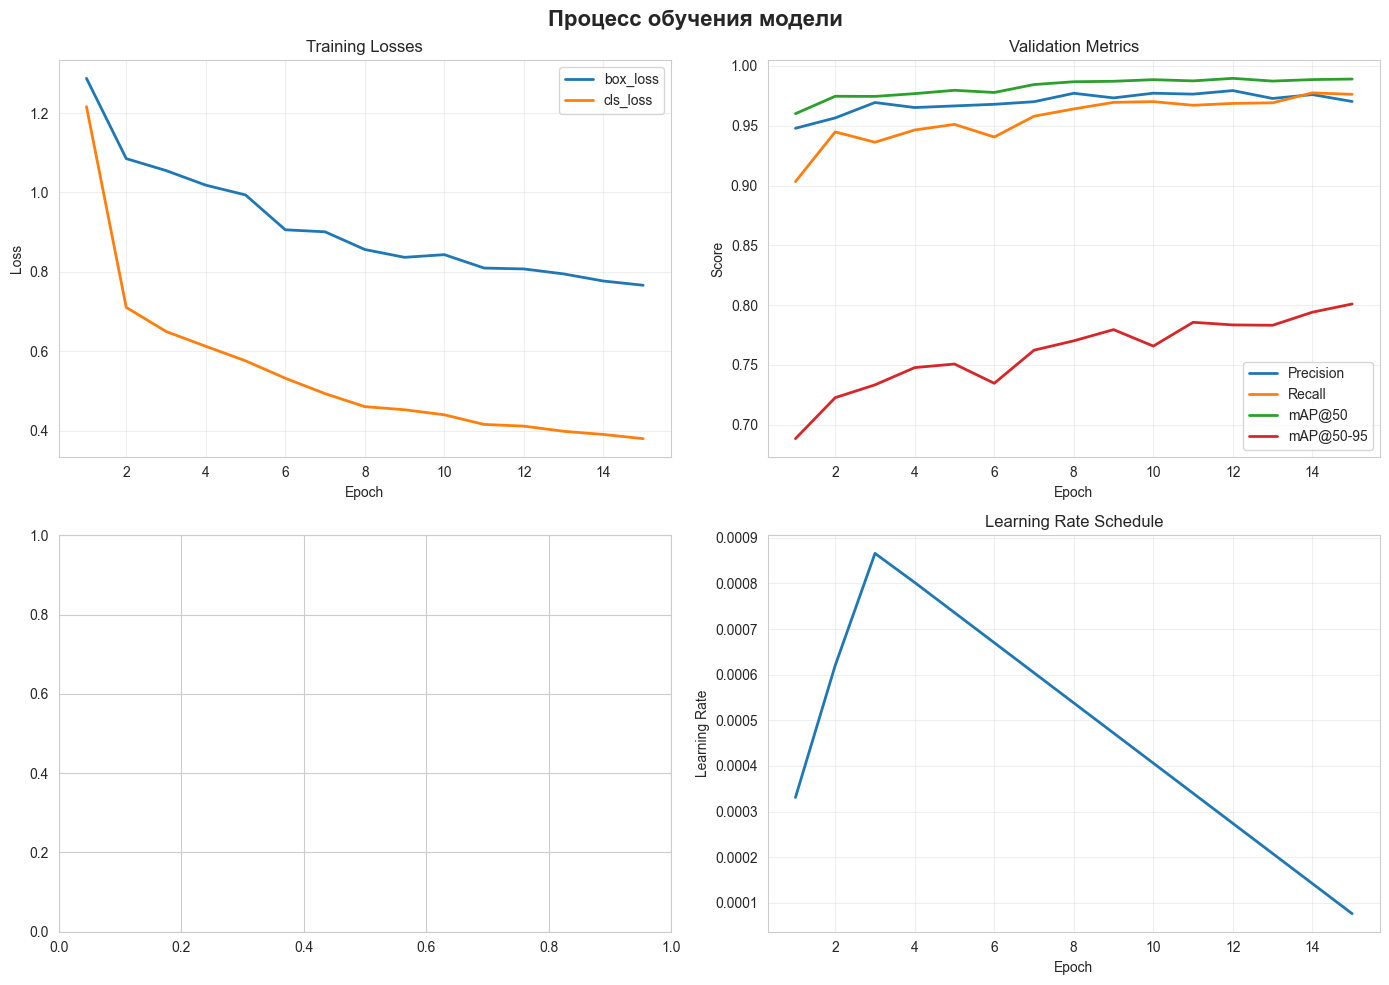


Финальные метрики на валидации:
   • Precision:  0.9702
   • Recall:     0.9762
   • mAP@50:     0.9890
   • mAP@50-95:  0.8010


In [ ]:
results_dir = Path(TRAIN_CONFIG['project']) / TRAIN_CONFIG['name']
metrics_file = "./runs/detect/runs/detect/lab3_plane_detection-3/results.csv"


metrics_df = pd.read_csv(metrics_file)

# Построение графиков
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Loss
axes[0, 0].plot(metrics_df['epoch'], metrics_df['train/box_loss'], label='box_loss', linewidth=2)
#axes[0, 0].plot(metrics_df['epoch'], metrics_df['train/obj_loss'], label='obj_loss', linewidth=2)
axes[0, 0].plot(metrics_df['epoch'], metrics_df['train/cls_loss'], label='cls_loss', linewidth=2)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Training Losses')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Metrics
axes[0, 1].plot(metrics_df['epoch'], metrics_df['metrics/precision(B)'], label='Precision', linewidth=2)
axes[0, 1].plot(metrics_df['epoch'], metrics_df['metrics/recall(B)'], label='Recall', linewidth=2)
axes[0, 1].plot(metrics_df['epoch'], metrics_df['metrics/mAP50(B)'], label='mAP@50', linewidth=2)
axes[0, 1].plot(metrics_df['epoch'], metrics_df['metrics/mAP50-95(B)'], label='mAP@50-95', linewidth=2)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Score')
axes[0, 1].set_title('Validation Metrics')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# F1 Score
if 'metrics/F1_score(B)' in metrics_df.columns:
    axes[1, 0].plot(metrics_df['epoch'], metrics_df['metrics/F1_score(B)'], 
                    color='purple', linewidth=2)
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('F1-Score')
    axes[1, 0].set_title('F1-Score on Validation')
    axes[1, 0].grid(alpha=0.3)

# Learning Rate
axes[1, 1].plot(metrics_df['epoch'], metrics_df['lr/pg0'], label='pg0', linewidth=2)
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Learning Rate')
axes[1, 1].set_title('Learning Rate Schedule')
axes[1, 1].grid(alpha=0.3)

plt.suptitle('Процесс обучения модели', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Финальные метрики
print("\nФинальные метрики на валидации:")
final_epoch = metrics_df.iloc[-1]
print(f"   • Precision:  {final_epoch['metrics/precision(B)']:.4f}")
print(f"   • Recall:     {final_epoch['metrics/recall(B)']:.4f}")
print(f"   • mAP@50:     {final_epoch['metrics/mAP50(B)']:.4f}")
print(f"   • mAP@50-95:  {final_epoch['metrics/mAP50-95(B)']:.4f}")
if 'metrics/F1_score(B)' in metrics_df.columns:
    print(f"F1-Score:   {final_epoch['metrics/F1_score(B)']:.4f}")


4. Оценка качества модели

In [22]:
val_results = model.val(
    data=str("data/plane/yolo_format/dataset.yaml"),
    split='test',
    imgsz=TRAIN_CONFIG['imgsz'],
    batch=16,
    device=TRAIN_CONFIG['device'],
    save_json=True,      # сохранить результаты в JSON
    save_conf=True,      # сохранить confidence scores
    plots=True           # построить графики
)

print("\nТестирование завершено!")

Ultralytics 8.4.53  Python-3.12.6 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
val: Fast image access  (ping: 0.60.2 ms, read: 409.8100.3 MB/s, size: 3814.6 KB)
val: Scanning C:\Users\Eugen\intro-to-neural-networks\lab3\data\plane\yolo_format\labels\test... 310 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 310/310 861.1it/s 0.4s0.1s
val: New cache created: C:\Users\Eugen\intro-to-neural-networks\lab3\data\plane\yolo_format\labels\test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 20/20 3.7it/s 5.4s0.2s
                   all        310       1924      0.981      0.954      0.982      0.787
Speed: 2.6ms preprocess, 3.9ms inference, 0.0ms loss, 1.9ms postprocess per image
Saving C:\Users\Eugen\intro-to-neural-networks\lab3\runs\detect\val-2\predictions.json...
Results saved to C:\Users\Eugen\intro-to-neural-networks\lab3\runs\detect\val-2

Тестирование завершено!


In [23]:
def calculate_detection_metrics(val_results, model, data_config, split='test'):
    metrics = {
        'mAP50': val_results.box.map50,
        'mAP50_95': val_results.box.map,
        'precision': val_results.box.mp,
        'recall': val_results.box.mr,
        'f1_score': 2 * (val_results.box.mp * val_results.box.mr) / 
                    (val_results.box.mp + val_results.box.mr + 1e-8)
    }
    if hasattr(val_results, 'iou'):
        metrics['mean_iou'] = np.mean(val_results.iou) if len(val_results.iou) > 0 else 0
    
    return metrics

detection_metrics = calculate_detection_metrics(val_results, model, DATA_ROOT)

# Вывод результатов
print("\nИтоговые метрики на тестовой выборке:")
print("=" * 50)
for metric_name, value in detection_metrics.items():
    if isinstance(value, float):
        print(f"   • {metric_name:15s}: {value:.4f}")
print("=" * 50)


Итоговые метрики на тестовой выборке:
   • mAP50          : 0.9816
   • mAP50_95       : 0.7868
   • precision      : 0.9808
   • recall         : 0.9542
   • f1_score       : 0.9673


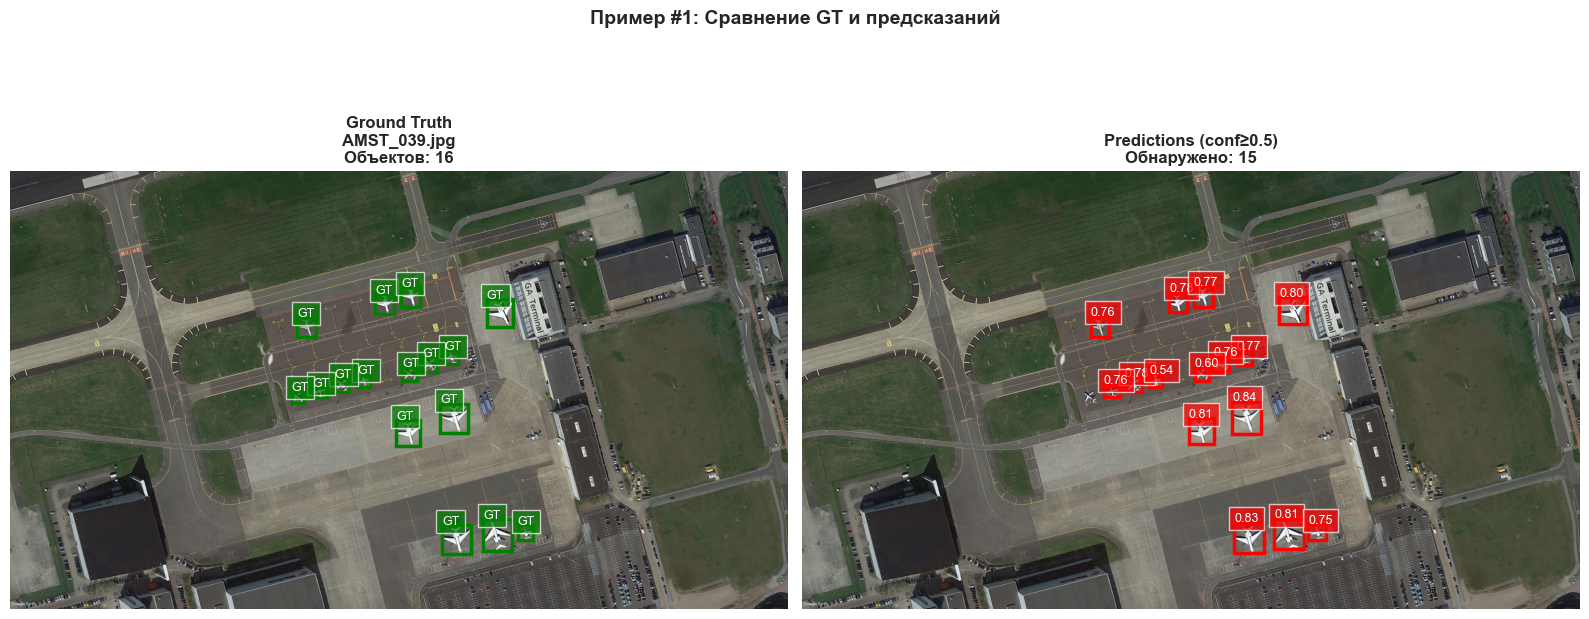

  Средний IoU для изображения: 0.767
------------------------------------------------------------


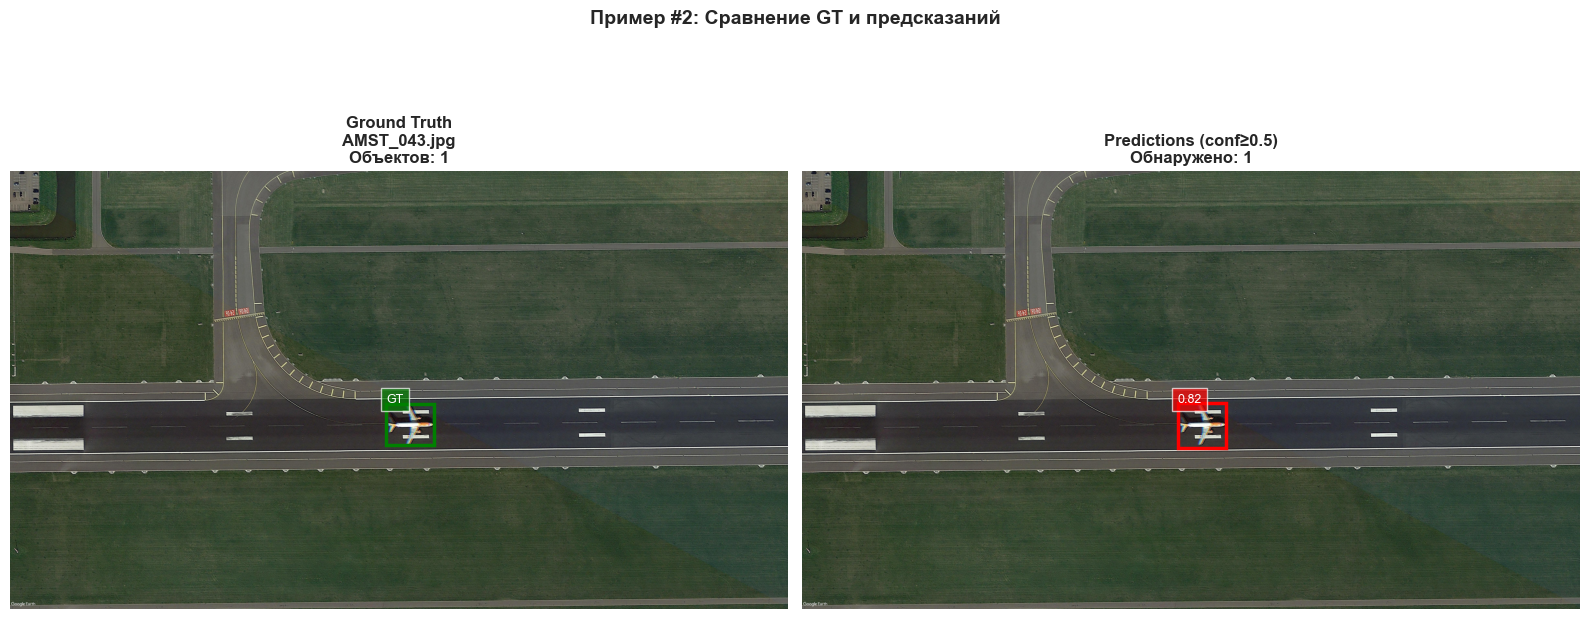

  Средний IoU для изображения: 0.901
------------------------------------------------------------


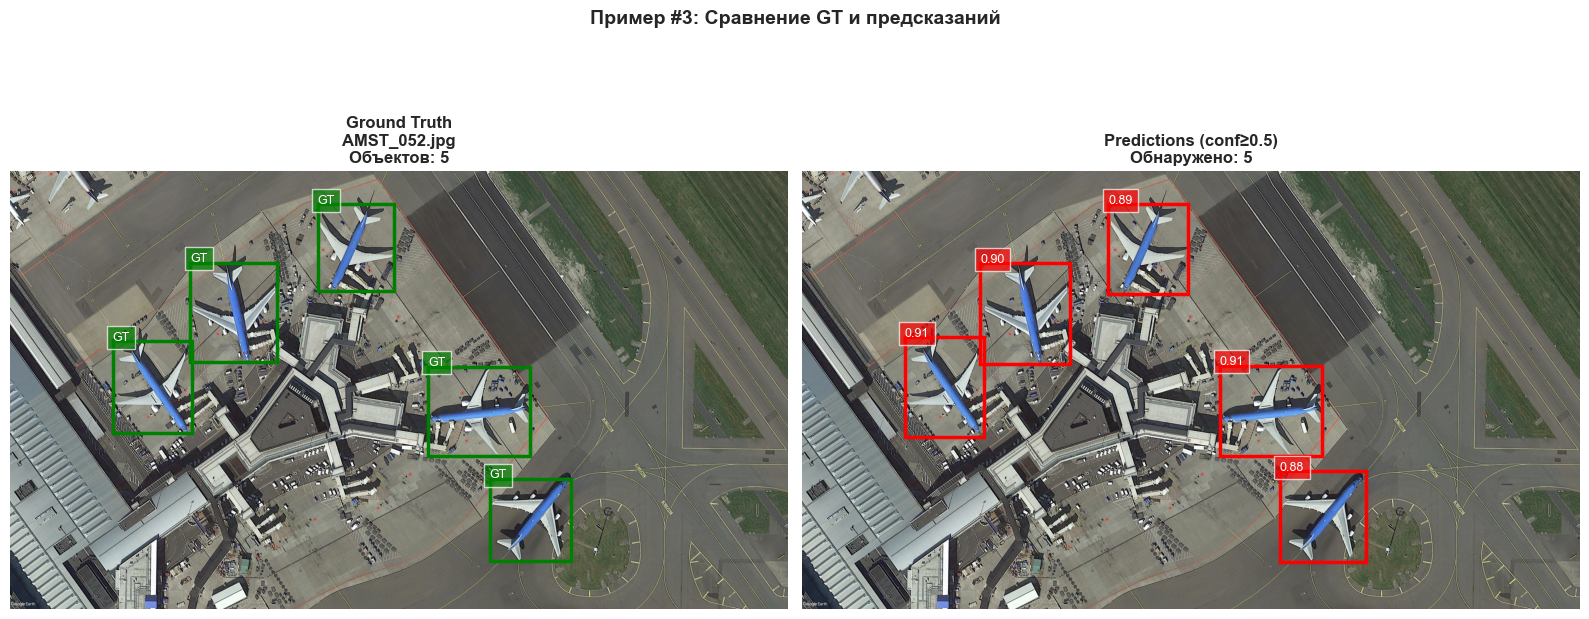

  Средний IoU для изображения: 0.924
------------------------------------------------------------


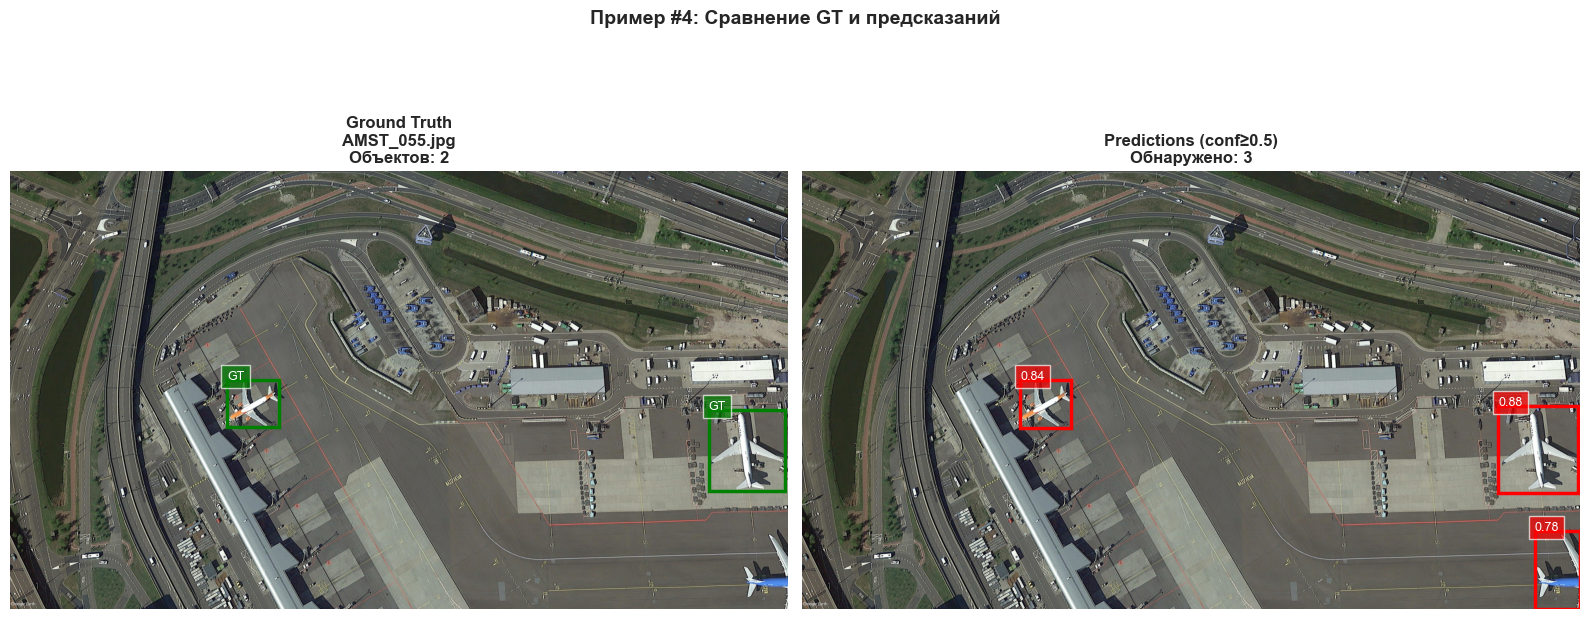

  Средний IoU для изображения: 0.924
------------------------------------------------------------


In [28]:
def visualize_predictions(model, num_samples=5, conf_thresh=0.5):
    images_dir = Path("data/plane/yolo_format/images/test")
    labels_dir = Path("data/plane/yolo_format/labels/test")
    
    image_paths = list(images_dir.glob("*.jpg"))[:num_samples]
    
    for idx, img_path in enumerate(image_paths, 1):
        # Загрузка изображения
        img = cv2.imread(str(img_path))
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img_rgb.shape[:2]
        
        # Ground truth аннотации
        label_path = labels_dir / img_path.with_suffix('.txt').name
        gt_bboxes = parse_yolo_annotation(str(label_path), w, h)
        
        # Предсказания модели
        results = model.predict(source=str(img_path), imgsz=640, conf=conf_thresh, verbose=False)
        pred_bboxes = []
        if results[0].boxes is not None:
            for box in results[0].boxes:
                x1, y1, x2, y2 = map(int, box.xyxy[0].cpu().numpy())
                conf = float(box.conf[0].cpu().numpy())
                cls = int(box.cls[0].cpu().numpy())
                pred_bboxes.append({'x1': x1, 'y1': y1, 'x2': x2, 'y2': y2, 
                                   'conf': conf, 'class_id': cls})
        
        # Визуализация
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
        
        # Ground Truth
        ax1.imshow(img_rgb)
        ax1.set_title(f'Ground Truth\n{img_path.name}\nОбъектов: {len(gt_bboxes)}', 
                     fontsize=12, fontweight='bold')
        for bbox in gt_bboxes:
            rect = plt.Rectangle((bbox['x1'], bbox['y1']), 
                               bbox['x2']-bbox['x1'], bbox['y2']-bbox['y1'],
                               fill=False, edgecolor='green', linewidth=2.5)
            ax1.add_patch(rect)
            ax1.text(bbox['x1'], bbox['y1']-5, 'GT', fontsize=9, 
                    bbox=dict(facecolor='green', alpha=0.7), color='white')
        ax1.axis('off')
        
        # Predictions
        ax2.imshow(img_rgb)
        ax2.set_title(f'Predictions (conf≥{conf_thresh})\nОбнаружено: {len(pred_bboxes)}', 
                     fontsize=12, fontweight='bold')
        for bbox in pred_bboxes:
            rect = plt.Rectangle((bbox['x1'], bbox['y1']), 
                               bbox['x2']-bbox['x1'], bbox['y2']-bbox['y1'],
                               fill=False, edgecolor='red', linewidth=2.5)
            ax2.add_patch(rect)
            ax2.text(bbox['x1'], bbox['y1']-5, f"{bbox['conf']:.2f}", fontsize=9, 
                    bbox=dict(facecolor='red', alpha=0.7), color='white')
        ax2.axis('off')
        
        plt.suptitle(f'Пример #{idx}: Сравнение GT и предсказаний', 
                    fontsize=14, fontweight='bold', y=1.02)
        plt.tight_layout()
        plt.show()
        
        # Расчёт метрик для этого изображения
        if gt_bboxes and pred_bboxes:
            ious = []
            for gt in gt_bboxes:
                gt_box = [gt['x1'], gt['y1'], gt['x2'], gt['y2']]
                best_iou = 0
                for pred in pred_bboxes:
                    pred_box = [pred['x1'], pred['y1'], pred['x2'], pred['y2']]
                    iou = calculate_iou(gt_box, pred_box)
                    best_iou = max(best_iou, iou)
                ious.append(best_iou)
            print(f"  Средний IoU для изображения: {np.mean(ious):.3f}")
        print("-" * 60)


visualize_predictions(model, num_samples=4)

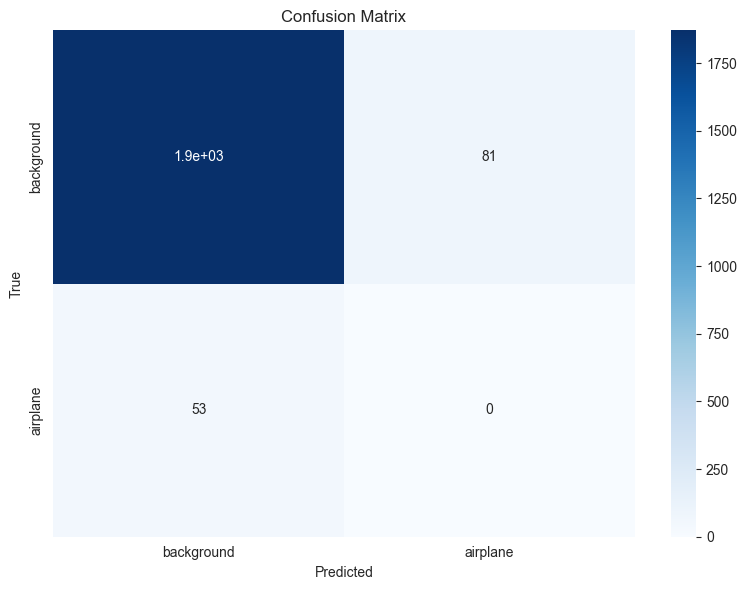

In [30]:
if hasattr(val_results, 'confusion_matrix') and val_results.confusion_matrix is not None:
    cm = val_results.confusion_matrix.matrix
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, cmap='Blues', 
                xticklabels=['background', 'airplane'],
                yticklabels=['background', 'airplane'])
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.tight_layout()
    plt.show()

if hasattr(val_results, 'results'):
    # Построение кривой (упрощённо)
    plt.figure(figsize=(8, 6))
    
    # Для одного класса: используем метрики из валидации
    recalls = np.linspace(0, 1, 100)
    precisions = np.interp(recalls, 
                          [0, detection_metrics['recall'], 1], 
                          [1, detection_metrics['precision'], 0])
    
    plt.plot(recalls, precisions, linewidth=2.5, label=f'AP = {detection_metrics["mAP50"]:.3f}')
    plt.fill_between(recalls, precisions, alpha=0.2)
    plt.xlabel('Recall', fontsize=12)
    plt.ylabel('Precision', fontsize=12)
    plt.title('Precision-Recall Curve', fontsize=14, fontweight='bold')
    plt.legend(fontsize=11)
    plt.grid(alpha=0.3)
    plt.xlim([0, 1])
    plt.ylim([0, 1.05])
    plt.tight_layout()
    plt.show()

In [32]:
def analyze_detection_errors(model, iou_thresh=0.5):
    from collections import defaultdict
    
    images_dir = Path("data/plane/yolo_format/images/test")
    labels_dir = Path("data/plane/yolo_format/labels/test")
    
    error_stats = defaultdict(list)
    
    image_paths = list(images_dir.glob("*.jpg"))
    
    for img_path in tqdm(image_paths, desc="Анализ ошибок"):
        img = cv2.imread(str(img_path))
        if img is None:
            continue
        h, w = img.shape[:2]
        
        # Ground truth
        label_path = labels_dir / img_path.with_suffix('.txt').name
        gt_bboxes = parse_yolo_annotation(str(label_path), w, h)
        
        # Predictions
        results = model.predict(source=str(img_path), imgsz=640, conf=0.25, verbose=False)
        pred_bboxes = []
        if results[0].boxes is not None:
            for box in results[0].boxes:
                x1, y1, x2, y2 = map(int, box.xyxy[0].cpu().numpy())
                conf = float(box.conf[0].cpu().numpy())
                pred_bboxes.append({'x1': x1, 'y1': y1, 'x2': x2, 'y2': y2, 'conf': conf})
        
        # Сопоставление предсказаний с истиной
        matched_gt = [False] * len(gt_bboxes)
        
        for pred in pred_bboxes:
            pred_box = [pred['x1'], pred['y1'], pred['x2'], pred['y2']]
            best_iou = 0
            best_gt_idx = -1
            
            for i, gt in enumerate(gt_bboxes):
                if matched_gt[i]:
                    continue
                gt_box = [gt['x1'], gt['y1'], gt['x2'], gt['y2']]
                iou = calculate_iou(pred_box, gt_box)
                if iou > best_iou:
                    best_iou = iou
                    best_gt_idx = i
            
            if best_iou >= iou_thresh and best_gt_idx >= 0:
                matched_gt[best_gt_idx] = True  # True Positive
            else:
                error_stats['false_positives'].append({
                    'image': img_path.name,
                    'bbox': pred,
                    'conf': pred['conf']
                })
        
        # False Negatives
        for i, gt in enumerate(gt_bboxes):
            if not matched_gt[i]:
                error_stats['false_negatives'].append({
                    'image': img_path.name,
                    'bbox': gt,
                    'area': (gt['x2']-gt['x1']) * (gt['y2']-gt['y1'])
                })
    
    return error_stats

errors = analyze_detection_errors(model)

print(f"\nСтатистика ошибок:")
print(f"   • False Positives: {len(errors['false_positives'])}")
print(f"   • False Negatives: {len(errors['false_negatives'])}")

# Анализ размеров пропущенных объектов
if errors['false_negatives']:
    fn_areas = [err['area'] for err in errors['false_negatives']]
    print(f"\nХарактеристики пропущенных объектов (FN):")
    print(f"   • Средний размер: {np.mean(fn_areas):.0f} px²")
    print(f"   • Медиана: {np.median(fn_areas):.0f} px²")
    print(f"   • Мин/Макс: {min(fn_areas):.0f} / {max(fn_areas):.0f} px²")

Анализ ошибок: 100%|██████████| 310/310 [00:53<00:00,  5.79it/s]


Статистика ошибок:
   • False Positives: 114
   • False Negatives: 58

Характеристики пропущенных объектов (FN):
   • Средний размер: 30609 px²
   • Медиана: 10348 px²
   • Мин/Макс: 750 / 405369 px²
